<a href="https://colab.research.google.com/github/Nickguild1993/McCombs_MBA_work/blob/main/save_differential_stats_homework_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stats homework for units 1-3 | Nicholas Guild, nbg296, 09/04/2025

In [ ]:
# import the usuals
import numpy as np
import pandas as pd
import math
# shockingly, need to use scipy
import scipy.stats as stats
import matplotlib.pyplot as plt

### Problem 1

### work

2 conditions that result in jackets on clearance -> challenging: 0.35, typical: 0.40 //// favorable: 0.25

Question 1

pr(x) = challenging(0.35) + typical(0.40) = 0.75 probability ~ 75% chance they'll need to put jackets on clearance

Question 2: Probability demand will be sufficient to sell entire order at full price? <br>
<br>
Favorable(0.25) is only condition that allows for that outcome <br>
0.25 probability, 25% chance none will need to go on sale



Question 3: FashionForward wants at least a 70% chance of selling everything at full price, what is
the maximum number of jackets they should order?

If they want a 70% chance to sell everything at full price, they should order 0 jackets because the number of jackets they order does not affect the static probabilities of X market outcome. The only scenario they sell everything at $120 has a probability of 0.25.  

Part B: Profit analysis

`P(Q,D) = 120 * min(Q,D) + 28 * max(Q-D,0)-68*Q`

In [ ]:
# variables
cogs = 68
retail = 120
clearnace = 28
###########
prob_challenging = 0.35
prob_typical = 0.40
prob_favorable = 0.25
##########
profit_challenging = 7600
profit_typical = 21400
profit_favorable = 26000


In [ ]:
# dataframe for 500 jackets

# data
data = {
    'CONDITION': ['challenging', 'typical', 'favorable'],
    'NUMBER_SOLD': [300, 450, 500],
    'NUMBER_ORDERED': [500, 500, 500],
    'PROBABILITY': [0.35, 0.40, 0.25],
    'PROFIT': [7600, 21400, 26000]
}

jackets_500_df = pd.DataFrame(data)

print(jackets_500_df)

     CONDITION  NUMBER_SOLD  NUMBER_ORDERED  PROBABILITY  PROFIT
0  challenging          300             500         0.35    7600
1      typical          450             500         0.40   21400
2    favorable          500             500         0.25   26000


Q1

In [ ]:
expected_value = (prob_challenging*profit_challenging) + (prob_typical*profit_typical) + (prob_favorable*profit_favorable)
print(f'EV for 500 jacket order is: ${expected_value}')

EV for 500 jacket order is: $17720.0


In [ ]:
jackets_500_df['EXPECTED_VALUE'] = expected_value

Q2 standard deviation of profit

In [ ]:
jackets_500_df['SQUARED_DEVIATION'] = (jackets_500_df['PROFIT'] - jackets_500_df['EXPECTED_VALUE'])**2

# multiply by corresponding prob
jackets_500_df['WEIGHTED_SQUARED_DEVIATION'] = jackets_500_df['SQUARED_DEVIATION'] * jackets_500_df['PROBABILITY']

In [ ]:
# sum weighted squared dev
variance = jackets_500_df['WEIGHTED_SQUARED_DEVIATION'].sum()
print(f'variance for 500 jacket order is: ${variance}')

variance for 500 jacket order is: $58401600.0


In [ ]:
# get the standard deviation
std_dev = math.sqrt(variance)
print(f'standard deviation for 500 jacket order is: ${std_dev:.2f}')

standard deviation for 500 jacket order is: $7642.09


In [ ]:
# add it into the df

jackets_500_df['STD_DEV'] = std_dev
#shouldn't of named it jackets_500_df lol
jackets_500_df.head(5)

,CONDITION,NUMBER_SOLD,NUMBER_ORDERED,PROBABILITY,PROFIT,EXPECTED_VALUE,SQUARED_DEVIATION,WEIGHTED_SQUARED_DEVIATION,STD_DEV
0,challenging,300,500,0.35,7600,17720.0,102414400.0,35845040.0,7642.093954
1,typical,450,500,0.40,21400,17720.0,13542400.0,5416960.0,7642.093954
2,favorable,500,500,0.25,26000,17720.0,68558400.0,17139600.0,7642.093954


In [ ]:
one_sd_below = expected_value - std_dev
one_sd_above = expected_value + std_dev

print(f'Range of 1 SD below expected value: ${one_sd_below:.2f}')
print(f'Range of 1 SD above expected value: ${one_sd_above:.2f}')

Range of 1 SD below expected value: $10077.91
Range of 1 SD above expected value: $25362.09


In [ ]:
cost = 34000

roi = (expected_value - cost) / cost
print(f'ROI for 500 jacket order is: {roi:.2%}')

ROI for 500 jacket order is: -47.88%


Standard deviation = $7642.01
What it tells us: This is a risky investment. The ROI on the expected value is -47.88%...not good!

Question 3: "conservative" order of 400 jackets

In [ ]:
# # profit formula

# P(Q,D) = 120 * min(Q,D) + 28 * max(Q-D,0)-68*Q

# need to establish new profits for each order, probabilities stay the same

In [ ]:
# variables
cogs = 68
retail = 120
clearance = 28
###########
prob_challenging = 0.35
prob_typical = 0.40
prob_favorable = 0.25
##########
profit_challenging = 7600
profit_typical = 21400
profit_favorable = 26000
##############
jacket_order = 400
##############
challenging_retail = 240
typical_retail = 360
favorable_retail = 400

In [ ]:
updated_challenging_profit = (retail * min(jacket_order, challenging_retail) + (clearance * max(jacket_order - challenging_retail, 0))) - (cogs * jacket_order)
updated_typical_profit = (retail * min(jacket_order, typical_retail) + (clearance * max(jacket_order - typical_retail, 0))) - (cogs * jacket_order)
updated_favorable_profit = (retail * min(jacket_order, favorable_retail) + (clearance * max(jacket_order - favorable_retail, 0))) - (cogs * jacket_order)
#
print(f'updated challenging profit: ${updated_challenging_profit}')
print(f'updated typical profit: ${updated_typical_profit}')
print(f'updated favorable profit: ${updated_favorable_profit}')


updated challenging profit: $6080
updated typical profit: $17120
updated favorable profit: $20800


In [ ]:
updated_expected_value = (prob_challenging * updated_challenging_profit) + (prob_typical * updated_typical_profit) + (prob_favorable * updated_favorable_profit)
print(f'updated EV for 400 jacket order is: ${updated_expected_value}')

updated EV for 400 jacket order is: $14176.0


In [ ]:
# recreate the dataframe for 400 jackets

updated_df = jackets_500_df.copy()

updated_df['PROFIT'] = [updated_challenging_profit, updated_typical_profit, updated_favorable_profit]
updated_df['EXPECTED_VALUE'] = updated_expected_value
updated_df['SQUARED_DEVIATION'] = (updated_df['PROFIT'] - updated_df['EXPECTED_VALUE'])**2
updated_df['WEIGHTED_SQUARED_DEVIATION'] = updated_df['SQUARED_DEVIATION'] * updated_df['PROBABILITY']
variance_new = updated_df['WEIGHTED_SQUARED_DEVIATION'].sum()
std_dev_new = math.sqrt(variance_new)
updated_df['STD_DEV'] = std_dev_new

In [ ]:
updated_df.head(5)

,CONDITION,NUMBER_SOLD,NUMBER_ORDERED,PROBABILITY,PROFIT,EXPECTED_VALUE,SQUARED_DEVIATION,WEIGHTED_SQUARED_DEVIATION,STD_DEV
0,challenging,300,500,0.35,6080,14176.0,65545216.0,22940825.6,6113.675163
1,typical,450,500,0.40,17120,14176.0,8667136.0,3466854.4,6113.675163
2,favorable,500,500,0.25,20800,14176.0,43877376.0,10969344.0,6113.675163


Q3: 400 Jacket results: EV:$ 14,176 Std dev: 6113.68

The expected value is understandably lower at 400 jackets vis-a-vis 500.  The standard deviation is also lower because the range of outcomes is tighter.  Meaning that the actual outcome is more likely to be closer to the mean.

In [ ]:
######################################################################

Question 4: Purchasing 100 additional jackets costs $6,800 (68/ea)
Cost of capital is 6%, could take that 6800 and invest in widgets with an expected return of 6% at similar levels of risk.

So the 100 added jackets is to the 400 jacket order, putting back at 500 jackets.

In [ ]:
# subtract 400 jacket EV from 500 jacket EV

excess_profit = expected_value - updated_expected_value
print(f'excess profit of purchasing 500 jackets vis-a-vis 400 is: ${excess_profit}')

excess profit of purchasing 500 jackets vis-a-vis 400 is: $3544.0


4a : **EXCESS PROFIT = $3,544**

In [ ]:
principal = 6800
rate_of_return = 0.06
ROI = principal * rate_of_return
print(f'ROI of investing the $6,800 in the new widget line is ${ROI}')

ROI of investing the $6,800 in the new widget line is $408.0


**4b: return on alternative investment: $408.00**

4c: I would place the 500 unit order instead of the alternative investment as the potential payoff is much higher

408.0

### Part C: Continuous Demand Analysis

New models who this <br>
Challenging market conditions: Demand ~ N(300, 50^2) units <br>
Typical market conditions: Demand ~ N(450,40^2) units <br>
Favorable market conditions: Demand ~ N(550, 50^2) units

1). 400 jacket order

In [ ]:
# what ist he probability of demand exceeding inventory for each condition

def calculate_probability(mean, std_dev, inventory):
  '''
  Calculates the probability of demand exceeding inventory for each of the three conditions

  Returns the probabiliyt of demand exceeding the jacket inventory.
  '''
  # z score calc
  z_score = (inventory - mean) / std_dev  # calc z score

  # use .cdf() to calculate cumulative probability that x value <= z-score. aka, unsold jackets
  less_than_or_equal_probability = stats.norm.cdf(z_score)

  # probability of demand exceeding inventory: 1 - prob that demand is <= inventory.
  prob_exceed_inventory = 1 - less_than_or_equal_probability

  return prob_exceed_inventory

### define em //// need to update based on the # ordered
inventory_400 = 400

# challenging
challenging_demand_mean = 300
challenging_std_dev = 50

# typical
typical_demand_mean = 450
typical_std_dev = 40

# favorable
favorable_demand_mean = 550
favorable_std_dev = 50

# calculate and print the probability for each condition
prob_challenging = calculate_probability(challenging_demand_mean, challenging_std_dev, inventory_400)
prob_typical = calculate_probability(typical_demand_mean, typical_std_dev, inventory_400)
prob_favorable = calculate_probability(favorable_demand_mean, favorable_std_dev, inventory_400)

print(f"probability of demand exceeding inventory for challenging market conditions: {prob_challenging:.3f}")
print(f"probability of demand exceeding inventory for typical market conditions: {prob_typical:.3f}")
print(f"probability of demand exceeding inventory for favorable market conditions: {prob_favorable:.3f}")

probability of demand exceeding inventory for challenging market conditions: 0.023
probability of demand exceeding inventory for typical market conditions: 0.894
probability of demand exceeding inventory for favorable market conditions: 0.999


400 jacket order
1. probability of demand exceeding inventory for challenging market conditions: 0.023 <br>
probability of demand exceeding inventory for typical market conditions: 0.894 <br>
probability of demand exceeding inventory for favorable market conditions: 0.999

In [ ]:
# 500 jackets
# inventory_500 = 500

# z_score_test = (500 - 300) / 50
# z_score_test

# just need to update the inventory level
inventory_500 = 500

# specifics for each outcome stay the same

prob_challenging = calculate_probability(challenging_demand_mean, challenging_std_dev, inventory_500)
prob_typical = calculate_probability(typical_demand_mean, typical_std_dev, inventory_500)
prob_favorable = calculate_probability(favorable_demand_mean, favorable_std_dev, inventory_500)

print(15*'--', "500 jacket order", 35*'--')
print(f"probability of demand exceeding inventory for challenging market conditions: {prob_challenging:.5f}")
print(f"probability of demand exceeding inventory for typical market conditions: {prob_typical:.3f}")
print(f'probability of demand exceeding inventory for favorable market conditions:{prob_favorable:.3f}')

------------------------------ 500 jacket order ----------------------------------------------------------------------
probability of demand exceeding inventory for challenging market conditions: 0.00003
probability of demand exceeding inventory for typical market conditions: 0.106
probability of demand exceeding inventory for favorable market conditions:0.841


had to bump out the challenging market condition probability of exceeding inventory 5 decimal places...

2. 500 jacket order <br>


probability of demand exceeding inventory for challenging market conditions: 0.00003 <br>
probability of demand exceeding inventory for typical market conditions: 0.106 <br>
probability of demand exceeding inventory for favorable market conditions:0.841

In [ ]:
# percent point function (ppf) practice, its the mean but its been a while

In [ ]:
# probability demand less than 0.50 under favorable conditions
# P (demand > inventory) < 0.50

# recall - fave mean - 550 // std_dev - 50
# target probability
target_cumulative_prob = 0.50

target_inventory_level = stats.norm.ppf(
    target_cumulative_prob,
    favorable_demand_mean,
    favorable_std_dev
)

print(f'Inventory level that ensures the probability of demand exceeding inventory is less than 0.50: {target_inventory_level:.0f} jackets, which is also the mean, ha')

Inventory level that ensures the probability of demand exceeding inventory is less than 0.50: 550 jackets, which is also the mean, ha


3. What inventory level ensures the probability of demand exceeding inventory is less than 0.50 under **favorable** conditions
<br>
Inventory level that ensures the probability of demand exceeding inventory is less than 0.50: 550 jackets, which is also the mean, ha

4) What inventory level ensures the probability of demand exceeding inventory is less than 0.20 under BOTH *CHALLENGING AND TYPICAL CONDITIONS*



Answer: **To ensure both, we'll need 484 jackets.**
<br>
The typical market faces a much higher demand, so we need more jackets to ensure the probability of running out is less than 0.20.  Therefore, the number of jackets for typical is more than good for challenging.  


In [ ]:
# If probabilty demand is less than 0.20 for typical, it works for challenging. So, 0.80 quantile

target_cumulative_prob = 0.80

typical_required_inventory_level = stats.norm.ppf(
    target_cumulative_prob,
    typical_demand_mean,
    typical_std_dev
)

print(f'Inventory level that ensures the probability of demand exceeding inventory is less than 0.80: {typical_required_inventory_level:.2f} jackets')

Inventory level that ensures the probability of demand exceeding inventory is less than 0.80: 483.66 jackets


In [ ]:
required_inventory_challenging = stats.norm.ppf(
    target_cumulative_prob,
    challenging_demand_mean,
    challenging_std_dev
)

print(f'Inventory level that ensures the probability of demand exceeding inventory is less than 0.80: {required_inventory_challenging:.2f} jackets')

Inventory level that ensures the probability of demand exceeding inventory is less than 0.80: 342.08 jackets


### PROBLEM 2: DIGITAL MARKETING

FRESHPLATE OPERATES A MEAL KIT SUBSCRIPTION, $120/WEEK. HOW TO ALLOCATE THEIR MARKETING BUDGET ACROSS THE CHANNELS TO MAX ROI?

FOCUS ON TWO CHANNELS, EACH RECEIVES $15,000 WEEKLY BUDGET. BOTH HAVE WEEK-TO-WEEK VARIABILITY, MAKING IT TOUGH TO DETERMINE THE PROPER CHANNEL MIX

TWO CHANNELS:


*   SEARCH ADVERTISING
*   SOCIAL MEDIA ADVERTISING



#### Part A: Multi-Channel-marketing-performance

In [ ]:
search_data = {
    'performance': ['strong_week', 'average_week', 'weak_week'],
    'probability' : [0.25, 0.50, 0.25],
    'leads_generated' : [3000,2200,1600],
    'purchases' : [240, 180, 120]
}

social_data = {
    'performance': ['strong_week', 'average_week', 'weak_week'],
    'probability' : [0.20, 0.60, 0.20],
    'leads_generated' : [6000,4500,3000],
    'purchases': [180,150,120]}

search_df = pd.DataFrame(search_data)
social_df = pd.DataFrame(social_data)

In [ ]:
search_df.head()

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase
0,strong_week,0.25,3000,240,15000,5.00,62.50
1,average_week,0.50,2200,180,15000,6.82,83.33
2,weak_week,0.25,1600,120,15000,9.38,125.00


In [ ]:
social_df.head()

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase
0,strong_week,0.2,6000,180,15000,2.50,83.33
1,average_week,0.6,4500,150,15000,3.33,100.00
2,weak_week,0.2,3000,120,15000,5.00,125.00


1. Probability search/social channel generate >150 purchases:


Search channel: 0.75

Social channel: 0.80

In [ ]:
# COST PER LEAD

# both channels cost 15,000 a month

social_df['budget'] = 15000
search_df['budget'] = 15000

social_df['cost_per_lead'] = social_df['budget'] / social_df['leads_generated']
search_df['cost_per_lead'] = search_df['budget'] / search_df['leads_generated']

# COST PER ACQUISITION

social_df['cost_per_purchase'] = social_df['budget'] / social_df['purchases']
search_df['cost_per_purchase'] = search_df['budget'] / search_df['purchases']

social_df[['cost_per_lead','cost_per_purchase']] = social_df[['cost_per_lead', 'cost_per_purchase']].round(2)
search_df[['cost_per_lead','cost_per_purchase']] = search_df[['cost_per_lead','cost_per_purchase']].round(2)

    performance  probability  leads_generated  purchases  budget  \
0   strong_week          0.2             6000        180   15000   
1  average_week          0.6             4500        150   15000   
2     weak_week          0.2             3000        120   15000   

   cost_per_lead  cost_per_purchase  
0           2.50              83.33  
1           3.33             100.00  
2           5.00             125.00  
........................................
    performance  probability  leads_generated  purchases  budget  \
0   strong_week         0.25             3000        240   15000   
1  average_week         0.50             2200        180   15000   
2     weak_week         0.25             1600        120   15000   

   cost_per_lead  cost_per_purchase  
0           5.00              62.50  
1           6.82              83.33  
2           9.38             125.00  


2. Calculate CPL and CPA

In [ ]:
print(10*'..', "THE ANSWER TO QUESTION 2: CPL AND CPA", 10*'..')
print('search dataframe')
print(search_df[['performance', 'cost_per_lead', 'cost_per_purchase']])
print(40*"..")
print('social dataframe')
print(social_df[['performance', 'cost_per_lead', 'cost_per_purchase']])
print(40*'--')

.................... THE ANSWER TO QUESTION 2: CPL AND CPA ....................
search dataframe
    performance  cost_per_lead  cost_per_purchase
0   strong_week           5.00              62.50
1  average_week           6.82              83.33
2     weak_week           9.38             125.00
................................................................................
social dataframe
    performance  cost_per_lead  cost_per_purchase
0   strong_week           2.50              83.33
1  average_week           3.33             100.00
2     weak_week           5.00             125.00
--------------------------------------------------------------------------------


3. MD considers week "successful" if channel achieves a CPA below $85. What is probability of a successful week for each channel (exclusively)

-- search channel: 0.75 probability of successful week
<br>
-- social channel: 0.2 probability of sucessful week

In [ ]:
search_df['successful_week'] = search_df['cost_per_purchase'] < 85
social_df['successful_week'] = social_df['cost_per_purchase'] < 85
print(search_df[['performance', 'successful_week', 'probability']])
print(40*'--')
print(social_df[['performance', 'successful_week','probability']])

    performance  successful_week  probability
0   strong_week             True         0.25
1  average_week             True         0.50
2     weak_week            False         0.25
--------------------------------------------------------------------------------
    performance  successful_week  probability
0   strong_week             True          0.2
1  average_week            False          0.6
2     weak_week            False          0.2


#### PART B

**Part B: Channel Performance Comparison**

1.   Calculate the expected number of leads, expected number of purchases, and expected
weekly profit for each channel. Assume each subscription generates $120 in weekly revenue.
2.   Calculate the standard deviation for the number of purchases from the search channel.
Round your answer to the nearest whole number. The social channels standard deviation is given from additional historical data as 32 purchases. Compare the risk/reward profile of the two channels.
3.    We should also consider profit from leads that convert in the future its possible that on a longer time horizon social might outperform search because it generates many additional leads at relatively low cost, some of whom will convert in time. Assume subscribers during the week of the campaign continue for at least one additional week without cancelling, and that unconverted leads may convert in the following week at no additional acquisition cost. We assume no additional variable costs beyond Week 1 acquisition, so continuing subscribers revenue counts fully as profit.

In [ ]:
# search_strong_cogs = 62.50
# search_average_cogs = 83.33
# search_weak_cogs = 125.00

# #####

# social_strong_cogs = 83.33
# social_average_cogs = 100.00
# social_weak_cogs = 125.00


social dataframe adding expected values

In [ ]:
# social df
social_expected_leads = (social_df['leads_generated'] * social_df['probability']).sum()
social_expected_purchases = (social_df['purchases'] * social_df['probability']).sum()

social_expected_revenue = social_expected_purchases * 120
social_expected_profit = social_expected_revenue - social_df['budget']

In [ ]:
# add them to the dataframe

social_df['expected_leads'] = social_expected_leads
social_df['expected_purchases'] = social_expected_purchases
social_df['expected_revenue'] = social_expected_revenue
social_df['expected_profit'] = social_expected_profit

social_df.head(5)

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase,successful_week,expected_leads,expected_purchases,expected_profit,expected_revenue
0,strong_week,0.2,6000,180,15000,2.50,83.33,True,4500.0,150.0,3000.0,18000.0
1,average_week,0.6,4500,150,15000,3.33,100.00,False,4500.0,150.0,3000.0,18000.0
2,weak_week,0.2,3000,120,15000,5.00,125.00,False,4500.0,150.0,3000.0,18000.0


search dataframe adding expected values

In [ ]:
search_expected_leads = (search_df['leads_generated'] * search_df['probability']).sum()
search_expected_purchases = (search_df['purchases'] * search_df['probability']).sum()

search_expected_revenue = search_expected_purchases * 120
search_expected_profit = search_expected_revenue - search_df['budget']

In [ ]:
# add to the search dataframe

search_df['expected_leads'] = search_expected_leads
search_df['expected_purchases'] = search_expected_purchases
search_df['expected_revenue'] = search_expected_revenue
search_df['expected_profit'] = search_expected_profit

search_df.head()

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase,successful_week,expected_leads,expected_purchases,expected_profit,expected_revenue
0,strong_week,0.25,3000,240,15000,5.00,62.50,True,2250.0,180.0,6600.0,21600.0
1,average_week,0.50,2200,180,15000,6.82,83.33,True,2250.0,180.0,6600.0,21600.0
2,weak_week,0.25,1600,120,15000,9.38,125.00,False,2250.0,180.0,6600.0,21600.0


1. expected values in the two dataframes below

In [ ]:
######################### SEARCH DATAFRAME ###########################
search_df.head() #####################################################
######################################################################

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase,successful_week,expected_leads,expected_purchases,expected_profit,expected_revenue
0,strong_week,0.25,3000,240,15000,5.00,62.50,True,2250.0,180.0,6600.0,21600.0
1,average_week,0.50,2200,180,15000,6.82,83.33,True,2250.0,180.0,6600.0,21600.0
2,weak_week,0.25,1600,120,15000,9.38,125.00,False,2250.0,180.0,6600.0,21600.0


In [ ]:
########################## SOCIAL DATAFRAME ############################
social_df.head() ######################################################
#######################################################################

,performance,probability,leads_generated,purchases,budget,cost_per_lead,cost_per_purchase,successful_week,expected_leads,expected_purchases,expected_profit,expected_revenue
0,strong_week,0.2,6000,180,15000,2.50,83.33,True,4500.0,150.0,3000.0,18000.0
1,average_week,0.6,4500,150,15000,3.33,100.00,False,4500.0,150.0,3000.0,18000.0
2,weak_week,0.2,3000,120,15000,5.00,125.00,False,4500.0,150.0,3000.0,18000.0


2. CALCULATE THE STD DEV FOR THE NUMBER OF PURCHASES FROM THE SEARCH CHANNEL.  STANDARD DEVIATION FOR SOCIAL CHANNEL IS GIVEN - 32 PUCRCHASES. COMPARE THE RISK/REWARD PROFILE

- I have calculated the SD for social channel by hand, using excel, and python and I cannot understand how its 32.  The variance is 360, which makes the sd ~ 19- am I insane??

- The standard deviation of purchases for the search channel is 42, which means that it's more volatile than the standard deviation of purchases for the social channel.  The ceiling of the search channel is higher, but at the cost of a degree of certainty offered by the social channel.

In [ ]:
expected_purchases = 180

search_df['purchase_variance_component'] = (search_df['purchases'] - expected_purchases)**2 * search_df['probability']
purchase_variance = search_df['purchase_variance_component'].sum()

purchase_std_dev = math.sqrt(purchase_variance)

print(f'standard deviation for search channel: {purchase_std_dev:.0f}')

standard deviation for search channel: 42


I've computed the standard deviation for the social channel by hand, in excel, and using python and I can't get a standard deviation of 32 for the social channel.

In [ ]:
# week 1 profit:

week_1 = 150 * 120 - 15000

3000

In [ ]:
#### 43164 = 3000 + 18000 + (4350 * r * 120)

#### 43164 = 21000 + (522000 * r)

#### 22164 = 522,000 * r

#### r = 22164/522000 = 0.0425

Question 3: r = 4.25%

In [ ]:
r = 22164/522000
print(f'conversion rate "r" required for social channel total profit to equal search is: {r:.4f} or {r*100:.2f}%')

conversion rate "r" required for social channel total profit to equal search is: 0.0425 or 4.25%


PART C CONTINUOUS DISTRIBUTIONS

In [ ]:
# normal distributions

search_mean = 180
search_std_dev = 42

social_mean = 150
social_std_dev = 32

# last week's results:
search_actual_purchases = 210
social_actual_purchases = 171

# z score calculations

search_z_score = (search_actual_purchases - search_mean) / search_std_dev
social_z_score = (social_actual_purchases - social_mean) / social_std_dev

print(f'z score for search channel: {search_z_score:.2f}')
print(f'z score for social channel: {social_z_score:.2f}')

z score for search channel: 0.71
z score for social channel: 0.66


Q3 1. Search had a more unexpected purchase count with a z score of 0.71 vis-a-vis 0.66 for social

Q3 2. The 171 isn't close to a top 5%.  To get a top 5% result you'd need a z score of 1.645+ which would result in a noticably higher number of purchases than 171.

Q3 3. Per the z-score table, a score of 0.66 is equiv to .7454% percentile.  to get a 95% you'd need a 1.645+ score.  

....

.....

......

.......

### BELOW IS SCRAP / TESTS

In [ ]:
# just to test the visual, need to align the cumulative prob
very_good_cumulative_prob = 0.80

very_good_inventory_level = stats.norm.ppf(
    very_good_cumulative_prob,
    favorable_demand_mean,
    favorable_std_dev
)

print(f'testing .80 for very good for visualization purposes:{very_good_inventory_level}')

testing .80 for very good for visualization purposes:592.0810616786457


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2556545996.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, pdf_challenging, label=f'Challenging Market ($\mu={challenging_demand_mean}, \sigma={challenging_std_dev}$)')
/tmp/ipython-input-2556545996.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, pdf_challenging, label=f'Challenging Market ($\mu={challenging_demand_mean}, \sigma={cha

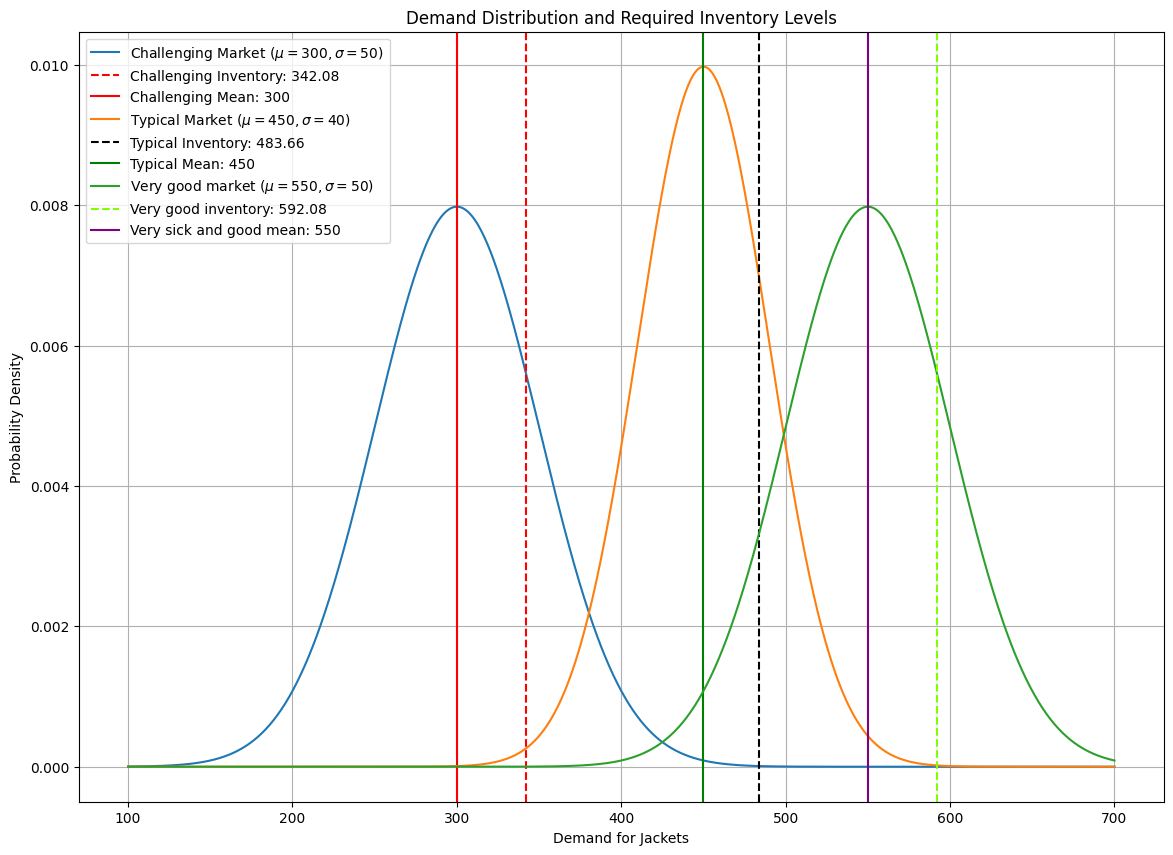

In [ ]:
# testing visual

x = np.linspace(100, 700, 1000)

# calc probability density function (PDF) for each market condition
pdf_challenging = stats.norm.pdf(x, loc=challenging_demand_mean, scale=challenging_std_dev)
pdf_typical = stats.norm.pdf(x, loc=typical_demand_mean, scale=typical_std_dev)
pdf_favorable = stats.norm.pdf(x, loc=favorable_demand_mean, scale=favorable_std_dev)

# Create the plot
plt.figure(figsize=(14, 10))


# Plot the challenging market distribution
plt.plot(x, pdf_challenging, label=f'Challenging Market ($\mu={challenging_demand_mean}, \sigma={challenging_std_dev}$)')
# Add a vertical line for the challenging market's required inventory
plt.axvline(
    x=required_inventory_challenging,
    color='r',
    linestyle='--',
    label=f'Challenging Inventory: {required_inventory_challenging:.2f}'
)
# Add a vertical line for the challenging market's mean
plt.axvline(
    x=challenging_demand_mean,
    color='r',
    linestyle='-',
    label=f'Challenging Mean: {challenging_demand_mean}'
)


# plot the typical market distribution
plt.plot(x, pdf_typical, label=f'Typical Market ($\mu={typical_demand_mean}, \sigma={typical_std_dev}$)')
# Add a vertical line for the typical market's required inventory
plt.axvline(
    x=typical_required_inventory_level,
    color='k',
    linestyle='--',
    label=f'Typical Inventory: {typical_required_inventory_level:.2f}'
)
# add a vertical line for the typical market's mean
plt.axvline(
    x=typical_demand_mean,
    color='g',
    linestyle='-',
    label=f'Typical Mean: {typical_demand_mean}'
)

# Plot the very good market distribution
plt.plot(x, pdf_favorable, label=f'Very good market ($\mu={favorable_demand_mean}, \sigma={favorable_std_dev}$)')
# Add a vertical line for the challenging market's required inventory
plt.axvline(
    x=very_good_inventory_level,
    color='chartreuse',
    linestyle='--',
    label=f'Very good inventory: {very_good_inventory_level:.2f}'
)
# Add a vertical line for the most excellent market's mean
plt.axvline(
    x=favorable_demand_mean,
    color='purple',
    linestyle='-',
    label=f'Very sick and good mean: {favorable_demand_mean}'
)



# Set the title and labels
plt.title('Demand Distribution and Required Inventory Levels')
plt.xlabel('Demand for Jackets')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# sub_profit = 120

search_df['expected_leads'] = search_df['leads_generated'] * search_df['probability']
search_df['expected_purchases'] = search_df['purchases'] * search_df['probability']
search_df['expected_profit'] = search_df['expected_purchases'] * 120

social_df['expected_leads'] = social_df['leads_generated'] * social_df['probability']
social_df['expected_purchases'] = social_df['purchases'] * social_df['probability']
social_df['expected_profit'] = social_df['expected_purchases'] * 120